(421570, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Type          421570 non-null  object        
 5   Size          421570 non-null  int64         
 6   Temperature   421570 non-null  float64       
 7   Fuel_Price    421570 non-null  float64       
 8   MarkDown1     421570 non-null  float64       
 9   MarkDown2     421570 non-null  float64       
 10  MarkDown3     421570 non-null  float64       
 11  MarkDown4     421570 non-null  float64       
 12  MarkDown5     421570 non-null  float64       
 13  CPI           421570 non-null  float64       
 14  Unemployment  421570 non-null  float64       
 15  Year

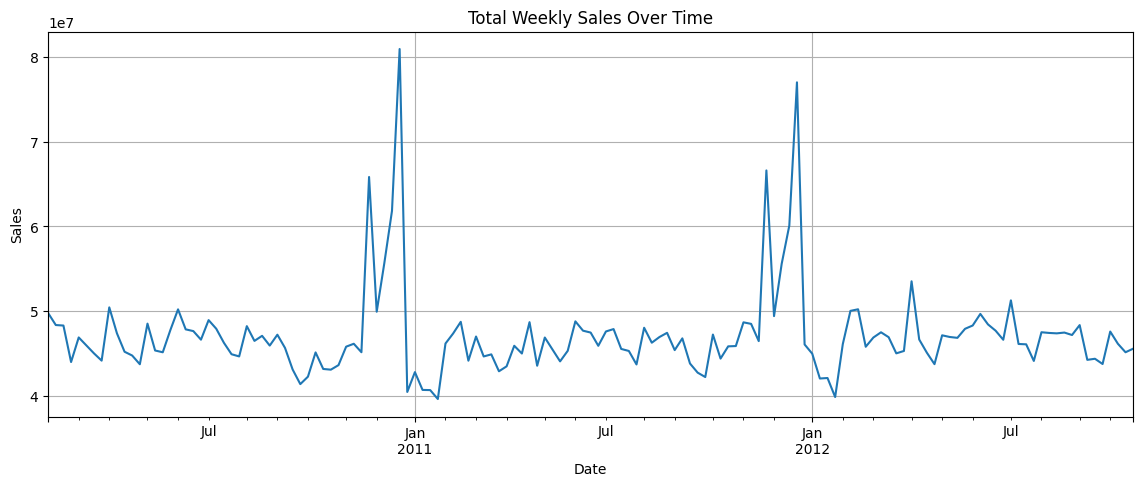

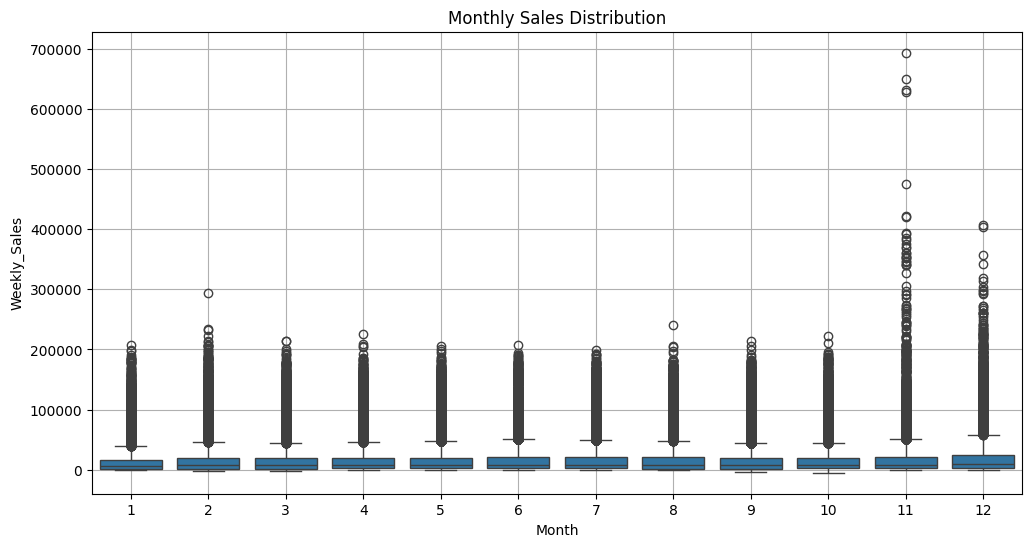

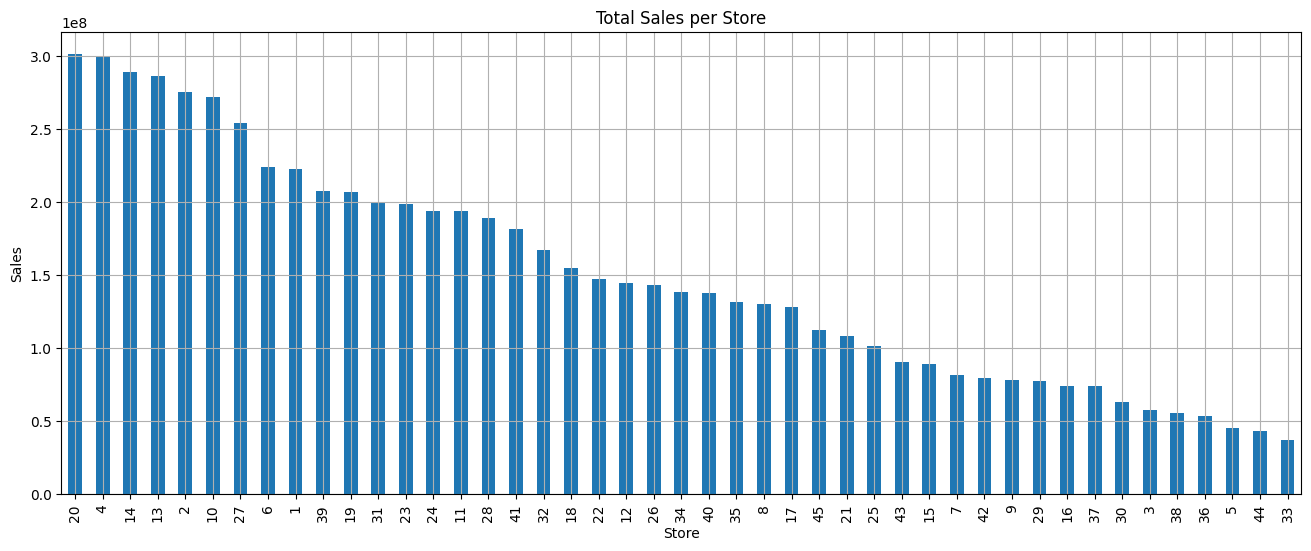

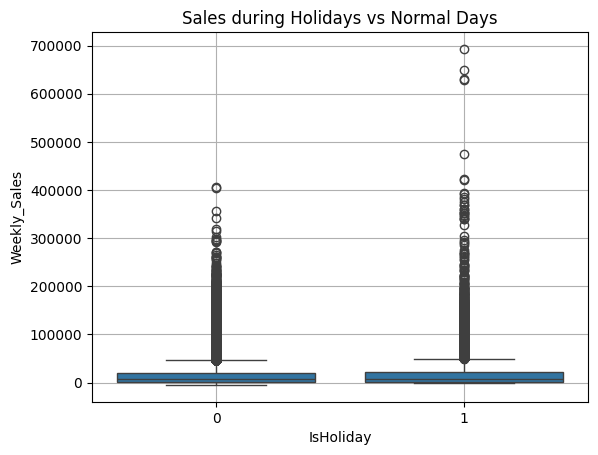

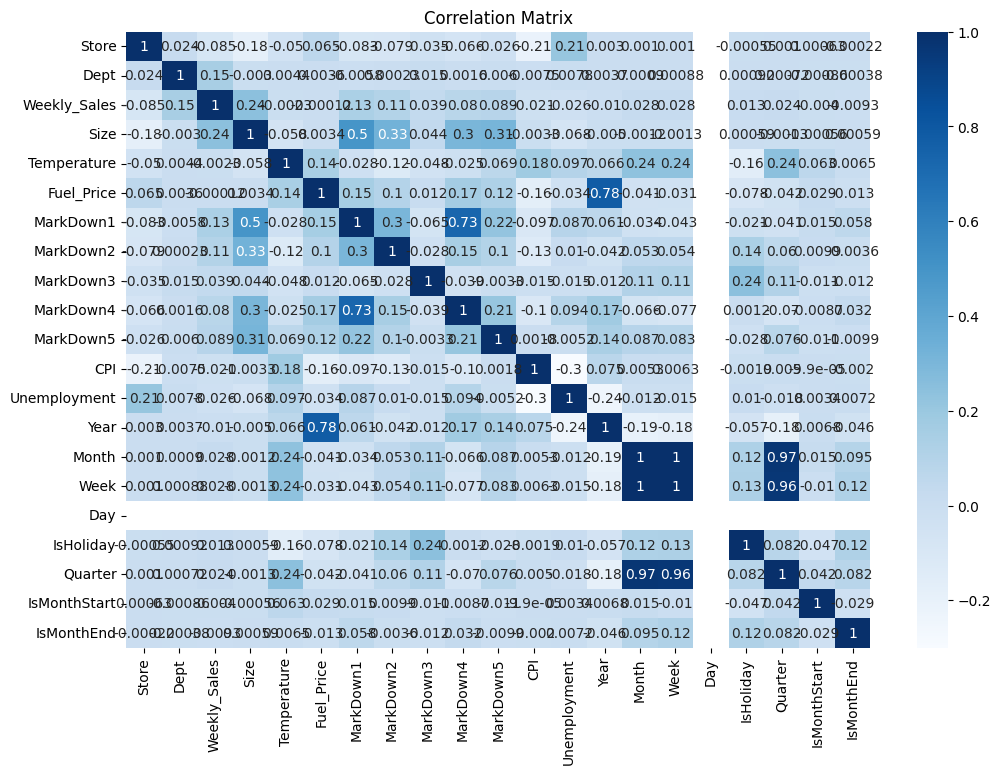

In [1]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load cleaned dataset
df = pd.read_csv('../data/processed/cleaned_walmart_data.csv', parse_dates=['Date'])

# 2. Basic stats
print(df.shape)
df.describe()
df.info()

# 3. Weekly Sales trend by date
plt.figure(figsize=(14, 5))
df.groupby("Date")["Weekly_Sales"].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# 4. Boxplot by month
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Month', y='Weekly_Sales')
plt.title("Monthly Sales Distribution")
plt.grid(True)
plt.show()

# 5. Sales distribution across stores
plt.figure(figsize=(16,6))
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
store_sales.plot(kind="bar")
plt.title("Total Sales per Store")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# 6. Impact of Holidays
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title("Sales during Holidays vs Normal Days")
plt.grid(True)
plt.show()

# 7. Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()